In [1]:
# ============================================================
# 03_baseline_evaluation_colab.ipynb
# Cell 1: Drive Mount, Runtime Check, Path Setup
# ============================================================

import os
import zipfile
from pathlib import Path

import torch
import pandas as pd
from google.colab import drive

# -----------------------------
# 1. Mount Google Drive
# -----------------------------
drive.mount("/content/drive")

# -----------------------------
# 2. Runtime check
# -----------------------------
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU is not available. Evaluation will run on CPU.")
    device = torch.device("cpu")

print("Using device:", device)

# -----------------------------
# 3. Define project paths
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis/thesis_project")

ZIP_PATH = Path("/content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip")

LOCAL_DATA_ROOT = Path("/content/data")
DATASET_PATH = LOCAL_DATA_ROOT / "PlantVillage"

DATA_DIR = PROJECT_ROOT / "data"

TEST_CSV = DATA_DIR / "test_files.csv"
LABEL_MAP_CSV = DATA_DIR / "label_map.csv"

BASELINE_DIR = PROJECT_ROOT / "01_baseline_before_optimization"
BASELINE_MODEL_DIR = BASELINE_DIR / "models"
BASELINE_RESULT_DIR = BASELINE_DIR / "results"

BEST_MODEL_PATH = BASELINE_MODEL_DIR / "mobilenetv2_baseline_best.pth"

BASELINE_RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("\nProject root:", PROJECT_ROOT)
print("Dataset zip:", ZIP_PATH)
print("Dataset path:", DATASET_PATH)
print("Test CSV:", TEST_CSV)
print("Label map CSV:", LABEL_MAP_CSV)
print("Best baseline model:", BEST_MODEL_PATH)
print("Baseline result directory:", BASELINE_RESULT_DIR)

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
Using device: cuda

Project root: /content/drive/MyDrive/Thesis/thesis_project
Dataset zip: /content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Dataset path: /content/data/PlantVillage
Test CSV: /content/drive/MyDrive/Thesis/thesis_project/data/test_files.csv
Label map CSV: /content/drive/MyDrive/Thesis/thesis_project/data/label_map.csv
Best baseline model: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_best.pth
Baseline result directory: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results


In [3]:
# ============================================================
# Improved Cell 2: Safe Dataset Extraction
# ============================================================

import shutil
import zipfile
from pathlib import Path

# -----------------------------
# 1. Re-define paths if needed
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis/thesis_project")
ZIP_PATH = Path("/content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip")

LOCAL_DATA_ROOT = Path("/content/data")
DATASET_PATH = LOCAL_DATA_ROOT / "PlantVillage"

LOCAL_ZIP_PATH = Path("/content/PlantVillage.zip")

# -----------------------------
# 2. Check Drive zip
# -----------------------------
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset zip file not found: {ZIP_PATH}")

print("Dataset zip found in Google Drive:")
print(ZIP_PATH)

# -----------------------------
# 3. Copy zip from Google Drive to Colab local storage
# -----------------------------
if not LOCAL_ZIP_PATH.exists():
    print("Copying zip file from Google Drive to Colab local storage...")
    shutil.copy2(ZIP_PATH, LOCAL_ZIP_PATH)
    print("Copy complete.")
else:
    print("Local zip already exists.")

print("Local zip path:", LOCAL_ZIP_PATH)
print("Local zip size MB:", round(LOCAL_ZIP_PATH.stat().st_size / (1024 * 1024), 2))

# -----------------------------
# 4. Remove partially extracted dataset if previous unzip failed
# -----------------------------
if DATASET_PATH.exists():
    print("Removing existing/partial dataset folder...")
    shutil.rmtree(DATASET_PATH)
    print("Old dataset folder removed.")

LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 5. Extract from local zip
# -----------------------------
print("Unzipping dataset from local zip...")
with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(LOCAL_DATA_ROOT)

print("Unzip complete.")

# -----------------------------
# 6. Verify dataset
# -----------------------------
print("Dataset exists:", DATASET_PATH.exists())
print("Dataset path:", DATASET_PATH)

class_dirs = sorted([p for p in DATASET_PATH.iterdir() if p.is_dir()])
print("Total class folders:", len(class_dirs))

Dataset zip found in Google Drive:
/content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Copying zip file from Google Drive to Colab local storage...
Copy complete.
Local zip path: /content/PlantVillage.zip
Local zip size MB: 817.19
Removing existing/partial dataset folder...
Old dataset folder removed.
Unzipping dataset from local zip...
Unzip complete.
Dataset exists: True
Dataset path: /content/data/PlantVillage
Total class folders: 38


In [4]:
# ============================================================
# Cell 3: Imports, Transform, and Test Dataset
# ============================================================

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# -----------------------------
# 1. Load CSV files
# -----------------------------
test_df = pd.read_csv(TEST_CSV)
label_map_df = pd.read_csv(LABEL_MAP_CSV)

num_classes = len(label_map_df)

print("Test images:", len(test_df))
print("Number of classes:", num_classes)

# -----------------------------
# 2. Configuration
# -----------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Device:", device)

# -----------------------------
# 3. Dataset class
# -----------------------------
class PlantVillageDataset(Dataset):
    def __init__(self, dataframe, dataset_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.dataset_root / row["relative_path"]
        label = int(row["label"])

        # Convert all images to RGB
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# -----------------------------
# 4. Test transform
# -----------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# -----------------------------
# 5. Create test dataset and dataloader
# -----------------------------
test_dataset = PlantVillageDataset(
    dataframe=test_df,
    dataset_root=DATASET_PATH,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if device.type == "cuda" else False
)

print("Test dataset size:", len(test_dataset))
print("Test batches:", len(test_loader))

# Check one batch
images, labels = next(iter(test_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Batch image dtype:", images.dtype)
print("Batch label dtype:", labels.dtype)

Test images: 5431
Number of classes: 38
Image size: 224
Batch size: 32
Device: cuda
Test dataset size: 5431
Test batches: 170
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Batch image dtype: torch.float32
Batch label dtype: torch.int64


In [5]:
# ============================================================
# Cell 4: Load Best Baseline Model
# ============================================================

# -----------------------------
# 1. Create MobileNetV2 architecture
# -----------------------------
baseline_model = models.mobilenet_v2(weights=None)

in_features = baseline_model.classifier[1].in_features
baseline_model.classifier[1] = nn.Linear(in_features, num_classes)

# -----------------------------
# 2. Load best checkpoint
# -----------------------------
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

baseline_model.load_state_dict(checkpoint["model_state_dict"])
baseline_model = baseline_model.to(device)
baseline_model.eval()

print("Best baseline model loaded successfully.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Best validation accuracy from checkpoint:", checkpoint["best_val_accuracy"])
print("Model device:", next(baseline_model.parameters()).device)
print("Classifier:")
print(baseline_model.classifier)

Best baseline model loaded successfully.
Checkpoint epoch: 9
Best validation accuracy from checkpoint: 0.9969310090842131
Model device: cuda:0
Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=38, bias=True)
)


In [7]:
# ============================================================
# Cell 5: Baseline Test Evaluation
# ============================================================

import time

baseline_model.eval()

all_preds = []
all_labels = []

test_start_time = time.time()

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Testing baseline model")

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = baseline_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

test_time = time.time() - test_start_time

# -----------------------------
# Calculate metrics
# -----------------------------
test_accuracy = accuracy_score(all_labels, all_preds)

test_precision_macro, test_recall_macro, test_f1_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

test_precision_weighted, test_recall_weighted, test_f1_weighted, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("Baseline test evaluation completed.")
print("Test images:", len(all_labels))
print("Test time seconds:", test_time)
print("Test time minutes:", test_time / 60)

print("\nTest Metrics:")
print("Accuracy:", test_accuracy)
print("Precision Macro:", test_precision_macro)
print("Recall Macro:", test_recall_macro)
print("F1 Macro:", test_f1_macro)

print("\nWeighted Metrics:")
print("Precision Weighted:", test_precision_weighted)
print("Recall Weighted:", test_recall_weighted)
print("F1 Weighted:", test_f1_weighted)

Testing baseline model: 100%|██████████| 170/170 [00:18<00:00,  9.29it/s]

Baseline test evaluation completed.
Test images: 5431
Test time seconds: 18.300354957580566
Test time minutes: 0.30500591595967613

Test Metrics:
Accuracy: 0.9972380777020806
Precision Macro: 0.9970410640122419
Recall Macro: 0.9945161237895173
F1 Macro: 0.9956856348556089

Weighted Metrics:
Precision Weighted: 0.9972959405805608
Recall Weighted: 0.9972380777020806
F1 Weighted: 0.9972303794104317


Baseline metrics saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_metrics.csv


,model_name,checkpoint_epoch,best_validation_accuracy,test_images,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted,colab_test_time_seconds,colab_test_time_minutes,device_used_for_this_evaluation,note
0,MobileNetV2 Baseline,9,0.996931,5431,0.997238,0.997041,0.994516,0.995686,0.997296,0.997238,0.99723,18.300355,0.305006,cuda,"This is Colab evaluation time, not final CPU l..."



Classification report saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_classification_report.csv


,precision,recall,f1-score,support
Apple___Apple_scab,1.0,1.0,1.0,63.0
Apple___Black_rot,1.0,1.0,1.0,62.0
Apple___Cedar_apple_rust,1.0,1.0,1.0,28.0
Apple___healthy,1.0,1.0,1.0,165.0
Blueberry___healthy,1.0,1.0,1.0,150.0



Confusion matrix CSV saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_confusion_matrix.csv


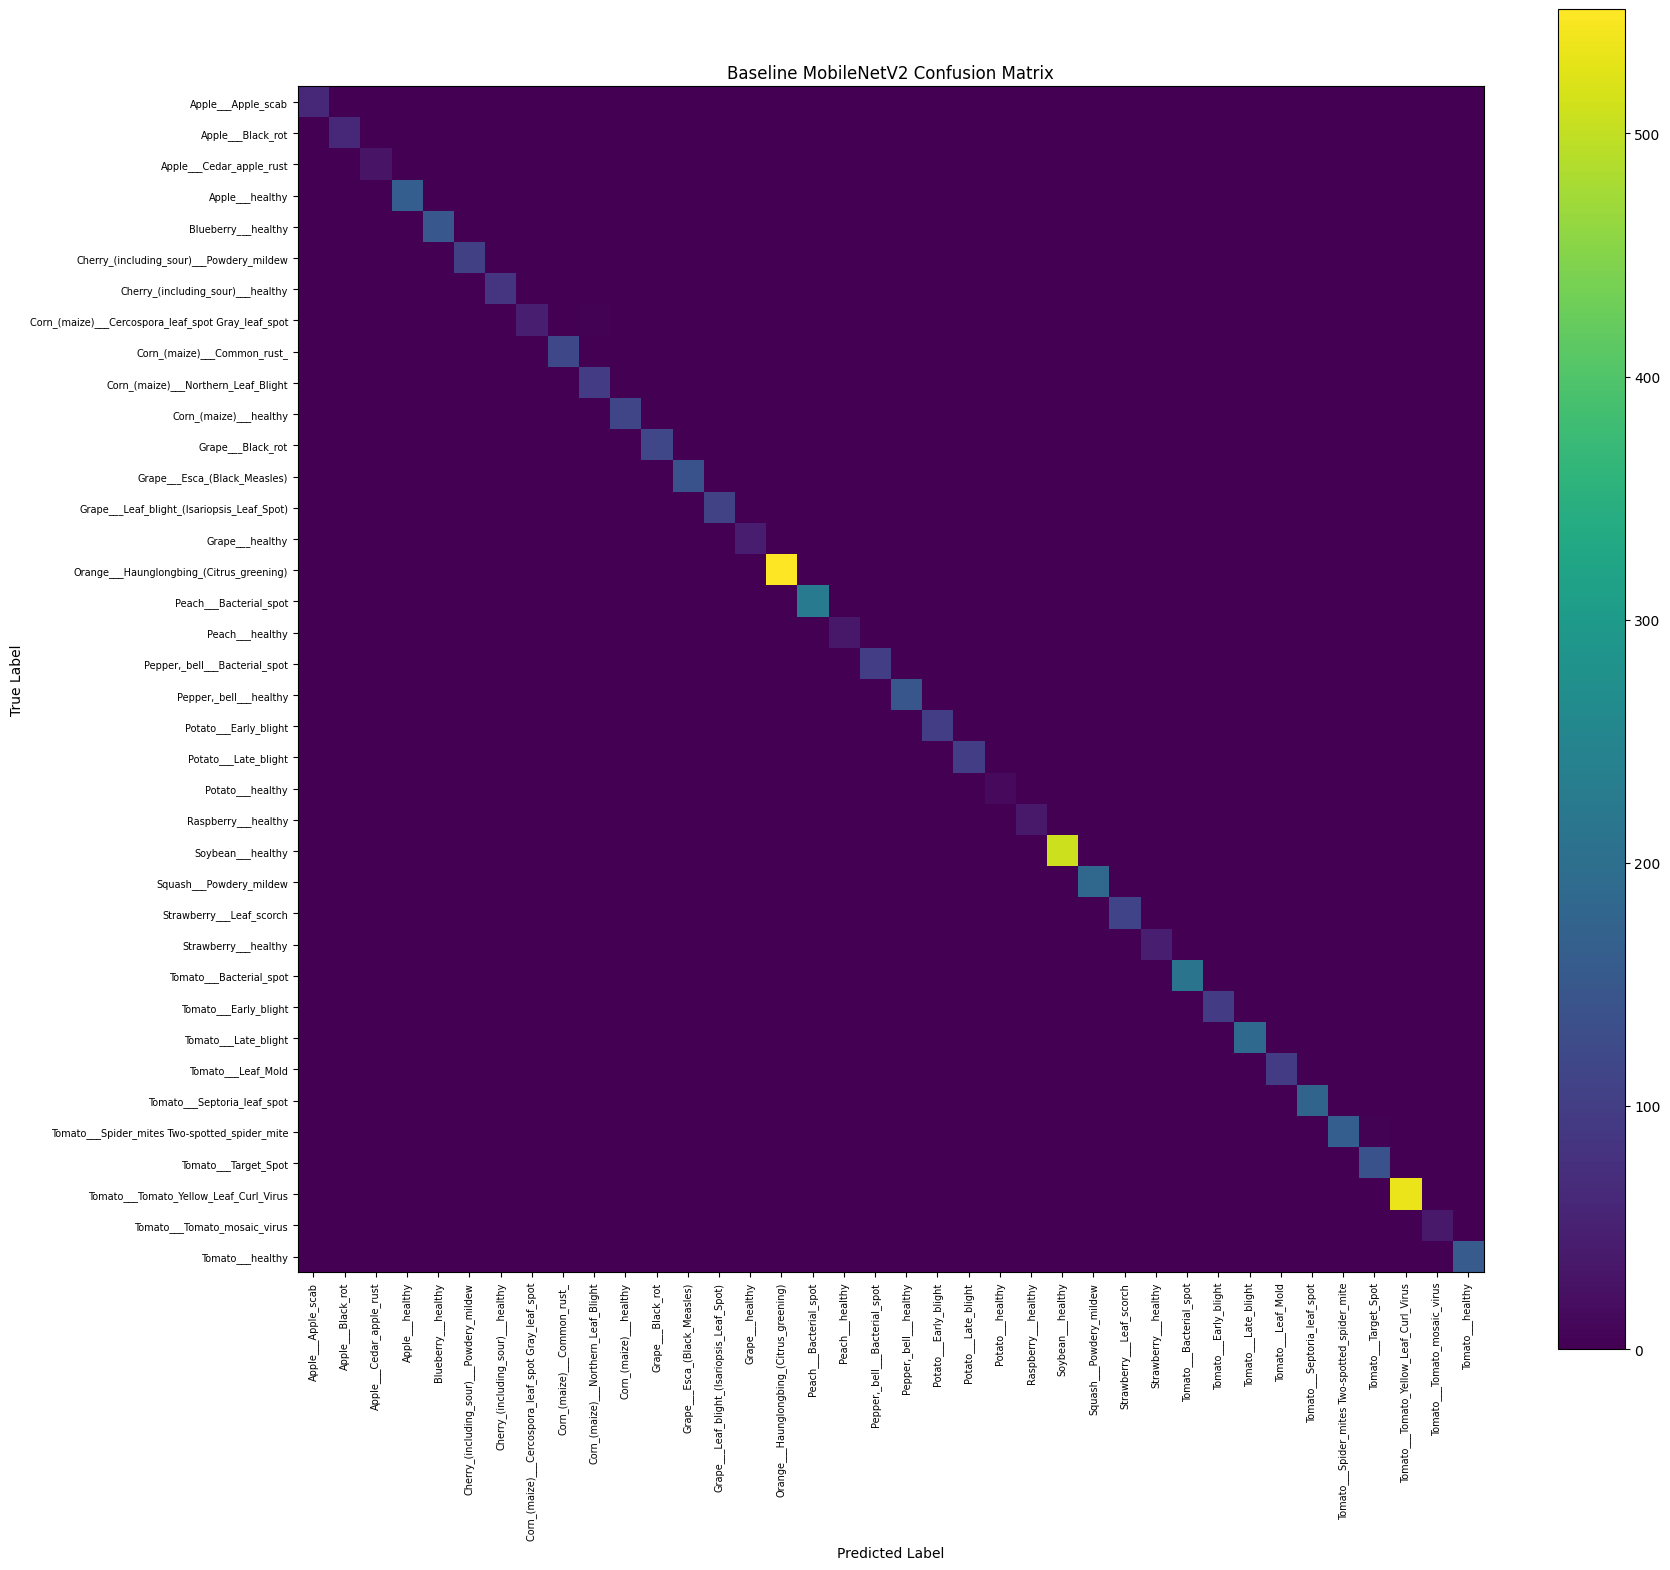


Confusion matrix image saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_confusion_matrix.png


In [8]:
# ============================================================
# Cell 6: Save Baseline Metrics, Classification Report, Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# 1. Prepare class names
# -----------------------------
label_map_df = label_map_df.sort_values("label").reset_index(drop=True)
class_names = label_map_df["class_name"].tolist()

# -----------------------------
# 2. Save overall baseline metrics
# -----------------------------
baseline_metrics = {
    "model_name": "MobileNetV2 Baseline",
    "checkpoint_epoch": checkpoint["epoch"],
    "best_validation_accuracy": checkpoint["best_val_accuracy"],
    "test_images": len(all_labels),
    "test_accuracy": test_accuracy,
    "test_precision_macro": test_precision_macro,
    "test_recall_macro": test_recall_macro,
    "test_f1_macro": test_f1_macro,
    "test_precision_weighted": test_precision_weighted,
    "test_recall_weighted": test_recall_weighted,
    "test_f1_weighted": test_f1_weighted,
    "colab_test_time_seconds": test_time,
    "colab_test_time_minutes": test_time / 60,
    "device_used_for_this_evaluation": str(device),
    "note": "This is Colab evaluation time, not final CPU latency/energy measurement."
}

baseline_metrics_df = pd.DataFrame([baseline_metrics])

baseline_metrics_path = BASELINE_RESULT_DIR / "baseline_metrics.csv"
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

print("Baseline metrics saved at:")
print(baseline_metrics_path)

display(baseline_metrics_df)

# -----------------------------
# 3. Save classification report
# -----------------------------
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose()

classification_report_path = BASELINE_RESULT_DIR / "baseline_classification_report.csv"
classification_report_df.to_csv(classification_report_path, index=True)

print("\nClassification report saved at:")
print(classification_report_path)

display(classification_report_df.head())

# -----------------------------
# 4. Save confusion matrix as CSV
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

confusion_matrix_csv_path = BASELINE_RESULT_DIR / "baseline_confusion_matrix.csv"
confusion_matrix_df.to_csv(confusion_matrix_csv_path, index=True)

print("\nConfusion matrix CSV saved at:")
print(confusion_matrix_csv_path)

# -----------------------------
# 5. Save confusion matrix image
# -----------------------------
plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("Baseline MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=7)
plt.yticks(tick_marks, class_names, fontsize=7)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

confusion_matrix_png_path = BASELINE_RESULT_DIR / "baseline_confusion_matrix.png"
plt.savefig(confusion_matrix_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nConfusion matrix image saved at:")
print(confusion_matrix_png_path)

In [9]:
# ============================================================
# Cell 7: Final Verification for Baseline Evaluation
# ============================================================

required_baseline_eval_files = [
    BASELINE_RESULT_DIR / "baseline_metrics.csv",
    BASELINE_RESULT_DIR / "baseline_classification_report.csv",
    BASELINE_RESULT_DIR / "baseline_confusion_matrix.csv",
    BASELINE_RESULT_DIR / "baseline_confusion_matrix.png",
]

print("Baseline evaluation output verification:\n")

all_ok = True

for file_path in required_baseline_eval_files:
    exists = file_path.exists()
    print(file_path.name, "->", exists)

    if not exists:
        all_ok = False

print("\nBaseline result folder files:")
for item in sorted(BASELINE_RESULT_DIR.iterdir()):
    print(item.name)

if all_ok:
    print("\nFile 03 completed successfully.")
else:
    print("\nSome files are missing. Please check the missing files above.")

Baseline evaluation output verification:

baseline_metrics.csv -> True
baseline_classification_report.csv -> True
baseline_confusion_matrix.csv -> True
baseline_confusion_matrix.png -> True

Baseline result folder files:
baseline_accuracy_curve.png
baseline_classification_report.csv
baseline_confusion_matrix.csv
baseline_confusion_matrix.png
baseline_loss_curve.png
baseline_metrics.csv
baseline_training_history.csv
baseline_training_summary.csv
baseline_val_f1_curve.png

File 03 completed successfully.
